In [ ]:
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from google.colab import drive, files
from PIL import Image

In [ ]:
# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define a persistent save path in your Drive
DRIVE_SAVE_PATH = '/content/drive/MyDrive/Satellite_Model/CNN_satellite_detection'

# 3. Create the directory if it doesn't exist
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

print(f"Model will be saved to: {DRIVE_SAVE_PATH}")

Mounted at /content/drive
Model will be saved to: /content/drive/MyDrive/Satellite_Model/CNN_satellite_detection


In [ ]:
print("Starting robust download of EuroSAT dataset from Academic Mirror...")

# --- 1. Data Download via Reliable Mirror (Zenodo/HuggingFace Backup) ---
# Bypassing the DFKI IP block by using a highly available community mirror
!wget https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip -O EuroSAT.zip

print("Download complete. Extracting files...")

# --- 2. Extraction and Cleanup ---
!unzip -q EuroSAT.zip -d 'EuroSAT/'
!rm EuroSAT.zip

# --- 3. Directory Verification ---
# Note: Depending on the mirror, the root folder might be named 'EuroSAT_RGB' instead of '2750'.
# We check for both common folder names to make the code unbreakable.
if os.path.exists('EuroSAT/EuroSAT_RGB'):
    DATA_DIR = 'EuroSAT/EuroSAT_RGB'
elif os.path.exists('EuroSAT/2750'):
    DATA_DIR = 'EuroSAT/2750'
else:
    raise Exception("CRITICAL ERROR: Extracted data directory not found. Please check the unzip output.")

CLASS_NAMES = sorted(os.listdir(DATA_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print("\n--- Dataset Loading Successful ---")
print(f"Data Directory Confirmed At: {DATA_DIR}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Class Names: {CLASS_NAMES}")

Starting robust download of EuroSAT dataset from Academic Mirror...
--2026-04-06 10:04:15--  https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 137.138.153.219, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/7711810/files/EuroSAT_RGB.zip [following]
--2026-04-06 10:04:16--  https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 94658721 (90M) [application/octet-stream]
Saving to: ‘EuroSAT.zip’

EuroSAT.zip         100%[===================>]  90.27M  18.4MB/s    in 6.2s    

2026-04-06 10:04:23 (14.5 MB/s) - ‘EuroSAT.zip’ saved [94658721/94658721]

Download complete. Extracting files...

--- Dataset Loading Successful ---
Data Directory Confirmed At: EuroSAT/EuroSAT_RGB
Number of Classes: 10
Class Names: 

In [ ]:
# Prepare Directories and Split Data

# Define the split ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Create a list of all file paths and their corresponding labels
filepaths = []
labels = []
for class_name in CLASS_NAMES:
    class_path = os.path.join(DATA_DIR, class_name)
    for filename in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, filename))
        labels.append(class_name)

# Convert to DataFrame for easy manipulation
data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})

# 1. Split into Training and (Validation + Test) - Stratified
X_train_val, X_test, y_train_val, y_test = train_test_split(
    data_df['filepath'],
    data_df['label'],
    test_size=TEST_RATIO,
    stratify=data_df['label'],
    random_state=42 # For reproducibility
)

# 2. Split (Validation + Test) into Validation and Test - Stratified
# Calculate validation ratio relative to the remaining data (train_val)
val_ratio_relative = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_ratio_relative,
    stratify=y_train_val,
    random_state=42
)

# Combine back into DataFrames
train_df = pd.DataFrame({'filepath': X_train, 'label': y_train})
val_df = pd.DataFrame({'filepath': X_val, 'label': y_val})
test_df = pd.DataFrame({'filepath': X_test, 'label': y_test})

print(f"\nTotal Images: {len(data_df)}")
print(f"Training Images: {len(train_df)} ({len(train_df)/len(data_df):.2%})")
print(f"Validation Images: {len(val_df)} ({len(val_df)/len(data_df):.2%})")
print(f"Test Images: {len(test_df)} ({len(test_df)/len(data_df):.2%})")


Total Images: 27000
Training Images: 18899 (70.00%)
Validation Images: 4051 (15.00%)
Test Images: 4050 (15.00%)


In [ ]:
# Data Generators

# Image parameters
IMG_SIZE = (64, 64) # EuroSAT images are 64x64 pixels
BATCH_SIZE = 32

# 1. Training Data Generator with Augmentation and Rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalization
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. Validation and Test Data Generator (only Rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create Generators from DataFrames
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Required for multi-class classification
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Shuffle is typically disabled for validation/test for deterministic evaluation
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Essential: Do NOT shuffle the test set
)

Found 18899 validated image filenames belonging to 10 classes.
Found 4051 validated image filenames belonging to 10 classes.
Found 4050 validated image filenames belonging to 10 classes.


In [ ]:
# The CNN Model

def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Classifier Head
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])

    return model

# Instantiate and compile the model
INPUT_SHAPE = IMG_SIZE + (3,) # (64, 64, 3) for RGB images
cnn_model = create_cnn_model(INPUT_SHAPE, NUM_CLASSES)

# Compilation
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),        # Optimizer: Adam is a common choice. I used a standard learning rate.
    loss='categorical_crossentropy',            # Loss: Categorical Crossentropy is the standard loss for multi-class classification
    metrics=['accuracy']
)

print(cnn_model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,296,138 (16.39 MB)

 Trainable params: 4,294,666 (16.38 MB)

 Non-trainable params: 1,472 (5.75 KB)

None


In [ ]:
# Train the Model

# Define Callbacks
model_filepath = os.path.join(DRIVE_SAVE_PATH, 'best_eurosat_cnn_model.keras')

# Saves the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    model_filepath,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Stops training if validation loss doesn't decrease for 10 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

# Training Parameters
EPOCHS = 50

# Train the model
history = cnn_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5115 - loss: 1.5966
Epoch 1: val_accuracy improved from None to 0.29968, saving model to /content/drive/MyDrive/Satellite_Model/CNN_satellite_detection/best_eurosat_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Satellite_Model/CNN_satellite_detection/best_eurosat_cnn_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 68s 90ms/step - accuracy: 0.5839 - loss: 1.2799 - val_accuracy: 0.2997 - val_loss: 3.1538
Epoch 2/50
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7059 - loss: 0.8676
Epoch 2: val_accuracy improved from 0.29968 to 0.51765, saving model to /content/drive/MyDrive/Satellite_Model/CNN_satellite_detection/best_eurosat_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Satellite_Model/CNN_satellite_detection/best_eurosat_cnn_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.7163 - loss: 0.8335 - val_accuracy: 0.5176 - val_loss: 1.8170
Epoch 3/5

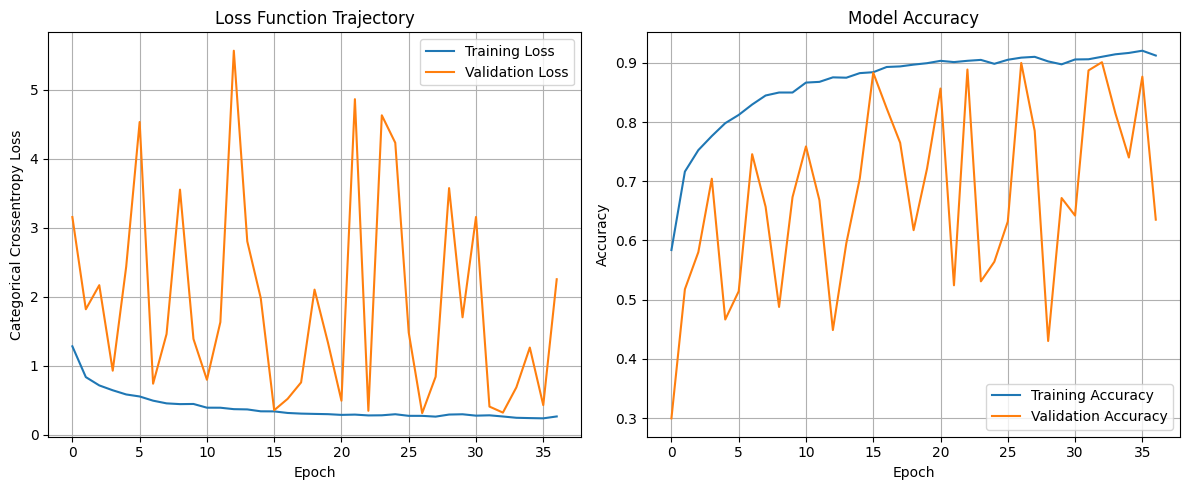

In [ ]:
# Plot Training History

def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Function Trajectory')
    plt.ylabel('Categorical Crossentropy Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

In [ ]:
# Final Evaluation and Prediction

# Load the best model weights
cnn_model.load_weights(model_filepath)

# 1. Final Evaluation (Test Loss and Accuracy)
print("--- Final Evaluation on Test Set ---")
loss, accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 2. Make Predictions on the Test Set
# The output is an array of predicted class probabilities (Softmax output)
STEP_SIZE_TEST = test_generator.n // test_generator.batch_size
test_generator.reset()
y_pred_probs = cnn_model.predict(test_generator, steps=STEP_SIZE_TEST + 1, verbose=1)

# Convert probabilities to class labels (index of the max probability)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Get the true class labels (indices)
y_true_classes = test_generator.classes[:len(y_pred_classes)]

# Get the class names in the order of the generator
class_labels = list(test_generator.class_indices.keys())

--- Final Evaluation on Test Set ---
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9123 - loss: 0.2642
Test Loss: 0.2642
Test Accuracy: 0.9123
127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step



--- Classification Report ---
                      precision    recall  f1-score   support

          AnnualCrop     0.9276    0.9400    0.9338       450
              Forest     0.9833    0.9156    0.9482       450
HerbaceousVegetation     0.7544    0.9556    0.8431       450
             Highway     0.9677    0.8800    0.9218       375
          Industrial     0.9938    0.8560    0.9198       375
             Pasture     0.9280    0.8167    0.8688       300
       PermanentCrop     0.8819    0.8560    0.8687       375
         Residential     0.8802    0.9956    0.9343       450
               River     0.9758    0.8587    0.9135       375
             SeaLake     0.9346    0.9844    0.9589       450

            accuracy                         0.9123      4050
           macro avg     0.9227    0.9058    0.9111      4050
        weighted avg     0.9202    0.9123    0.9130      4050



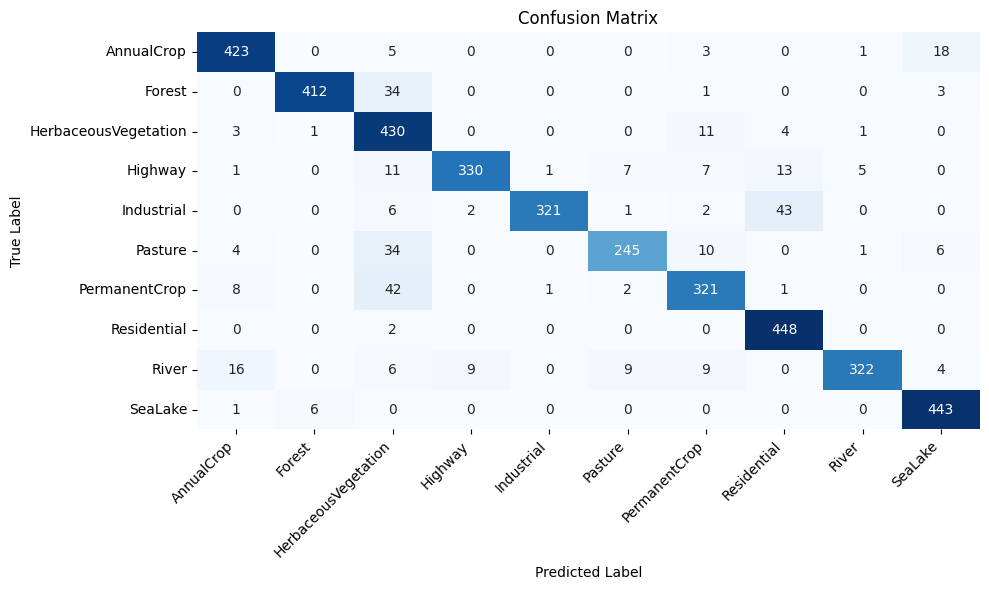

In [ ]:
#Classification Report and Confusion Matrix

# 1. Classification Report
print("\n--- Classification Report ---")
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels, digits=4)
print(report)

# 2. Confusion Matrix Calculation
cm = confusion_matrix(y_true_classes, y_pred_classes)

# 3. Visualization using Seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Define constants
IMG_SIZE = (64, 64)
CLASS_NAMES = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake'] # Copy this directly from your training notebook


DRIVE_LOAD_PATH = '/content/drive/MyDrive/Satellite_Model/CNN_satellite_detection/best_eurosat_cnn_model.keras'

# Mount Drive to access the saved model
drive.mount('/content/drive')

# --- 2. Load the Model (Run this once) ---
print("Loading model from Google Drive...")
try:
    best_model = tf.keras.models.load_model(DRIVE_LOAD_PATH)
    print("Model loaded successfully!")
except Exception as e:
    print(f"ERROR: Could not load model from path. Check the path and file existence: {e}")
    exit()

# --- 3. Inference Function (Re-use from Block 4.0) ---
def preprocess_and_predict(image_path, model, class_names, target_size):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size)
    img_array = np.array(img, dtype='float32')
    normalized_img = img_array / 255.0
    input_tensor = np.expand_dims(normalized_img, axis=0)

    prediction_probs = model.predict(input_tensor, verbose=0)[0]
    predicted_class_index = np.argmax(prediction_probs)
    predicted_label = class_names[predicted_class_index]
    confidence = prediction_probs[predicted_class_index]

    return img_array.astype(np.uint8), predicted_label, confidence

# --- 4. Test a New Picture (Run this repeatedly for new tests) ---
print("\nReady for image upload. Please click 'Choose Files'.")
uploaded = files.upload()

if uploaded:
    uploaded_file_name = list(uploaded.keys())[0]

    # Perform prediction
    image_original, label, confidence = preprocess_and_predict(
        uploaded_file_name,
        best_model,
        CLASS_NAMES,
        IMG_SIZE
    )

    # Visualization
    plt.figure(figsize=(6, 6))
    plt.imshow(image_original)
    plt.title(f"Prediction: {label}\nConfidence: {confidence*100:.2f}%",
              fontsize=14, color='green')
    plt.axis('off')
    plt.show()

    print(f"\nPredicted Class: {label}, Confidence: {confidence:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading model from Google Drive...
Model loaded successfully!

Ready for image upload. Please click 'Choose Files'.
